# Lab Assignment 19: Confidence Intervals (2)

**Helpful Resource:**

- [Python Reference](http://data8.org/sp24/reference/): Cheat sheet of helpful array & table methods!

**Recommended Reading**:

* [Estimation](https://www.inferentialthinking.com/chapters/13/Estimation)

In [1]:
!apt-get install texlive texlive-xetex texlive-latex-extra pandoc
!pip install pypandoc
!pip install datascience

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (2.9.2.1-3ubuntu2).
pandoc set to manually installed.
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries
  texlive-fonts-recommended texlive-latex-base texlive-latex-recommended
  texlive-pictures texlive-plain-generic tipa xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto f

In [2]:
# Connect Google Drive to Colab so you can access your files
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/Colab Notebooks/')

Mounted at /content/drive


In [3]:
# Don't change this cell; just run it.

import numpy as np
from datascience import *

# These lines do some fancy plotting magic.",
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import warnings
warnings.simplefilter('ignore', FutureWarning)

## 1. Thai Restaurants in Berkeley (for this section, copy your results of lec18(SSU))

Jessica and Ciara are trying to see what the best Thai restaurant in Berkeley is. They survey 1,500 UC Berkeley students selected uniformly at random and ask each student which Thai restaurant is the best. (*Note: This data is fabricated for the purposes of this homework.*) The choices of Thai restaurants are [Lucky House](https://www.google.com/maps/place/Lucky+House+Thai+Cuisine/@37.8707428,-122.270045,15.32z/data=!4m5!3m4!1s0x80857e9e69a8c921:0x7b6d80f58406fb26!8m2!3d37.8721393!4d-122.2672699), [Imm Thai](https://www.google.com/maps/place/Imm+Thai+Street+Food/@37.8704926,-122.2687372,15.51z/data=!4m5!3m4!1s0x80857e9eec4f1e63:0x5f54d96f0dccdb72!8m2!3d37.8719079!4d-122.2691186), [Thai Temple](https://www.google.com/maps/place/Wat+Mongkolratanaram/@37.8689514,-122.2698649,14.75z/data=!4m5!3m4!1s0x80857e886e39daf1:0xe309caa1b5710fc0!8m2!3d37.8563633!4d-122.2707584), and [Thai Basil](https://www.google.com/maps/place/Thai+Basil/@37.8691911,-122.266539,15.37z/data=!4m5!3m4!1s0x80857c2f6ae0e2f1:0x6978b6e8a72d58d4!8m2!3d37.868327!4d-122.258081). After compiling the results, Jessica and Ciara release the following percentages of votes that each restaurant received, from their sample:

|Thai Restaurant  | Percentage|
|:------------:|:------------:|
|Lucky House | 8% |
|Imm Thai | 53% |
|Thai Temple | 25% |
|Thai Basil | 14% |

These percentages represent a uniform random sample of the population of UC Berkeley students. We will attempt to estimate the corresponding *parameters*, or the percentage of the votes that each restaurant will receive from the population (i.e. all UC Berkeley students). We will use confidence intervals to compute a range of values that reflects the uncertainty of our estimates.

The table `votes` contains the results of Jessica and Ciara's survey.

In [4]:
# Just run this cell
votes = Table.read_table('./DS/votes.csv')
votes

Vote
Lucky House
Lucky House
Lucky House
Lucky House
Lucky House
Lucky House
Lucky House
Lucky House
Lucky House
Lucky House


**Question 1.1.** Complete the function `one_resampled_percentage` below. It should return Imm Thai's ***percentage*** of votes after taking the original table (`tbl`) and performing one bootstrap sample of it. Remember that a percentage is between 0 and 100. **(8 Points)**

*Note 1:* `tbl` will always be in the same format as `votes`.

*Note 2:* This function should be completed **without** `.group` or `.pivot`. Using these functions will cause your code to timeout.

*Hint:* Given a table of votes, how can you figure out what percentage of the votes are for a certain restaurant? **Be sure to use percentages, not proportions, for this question!**


In [11]:
def one_resampled_percentage(tbl):
    bootstrap = tbl.sample()
    imm_votes = bootstrap.where('Vote', are.equal_to('Imm Thai')).num_rows
    total_votes = bootstrap.num_rows
    return (imm_votes / total_votes) * 100

one_resampled_percentage(votes)

53.06666666666666

**Question 1.2.** Complete the `percentages_in_resamples` function such that it simulates and returns an array of **2023 elements**, where each element represents a bootstrapped estimate of the percentage of voters who will vote for Imm Thai. You should use the `one_resampled_percentage` function you wrote above. **(8 Points)**

_Note:_ We perform our simulation with **only 2023 trials** in this problem to reduce the runtime, but we should generally use more repetitions.


In [13]:
def percentages_in_resamples():
    percentage_imm = make_array()
    for i in np.arange(2023):
        percentage_imm = np.append(percentage_imm, one_resampled_percentage(votes))
    return percentage_imm

In the following cell, we run the function you just defined, `percentages_in_resamples`, and create a histogram of the calculated statistic for the 2023 bootstrap estimates of the percentage of voters who voted for Imm Thai.

*Note:* This might take a few seconds to run.

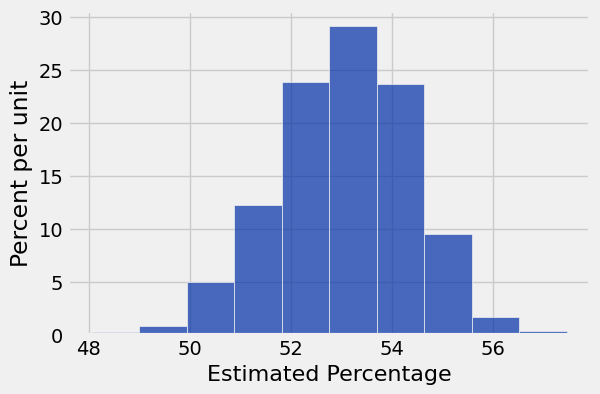

In [14]:
resampled_percentages = percentages_in_resamples()
Table().with_column('Estimated Percentage', resampled_percentages).hist("Estimated Percentage")

**Question 1.3.** Using the array `resampled_percentages`, find the values at the two edges of the middle 95% of the bootstrapped percentage estimates. Compute the lower and upper ends of the interval, named `imm_lower_bound` and `imm_upper_bound` respectively. **(8 Points)**

*Hint:* If you are stuck on this question, try looking over [Chapter 13.1](https://inferentialthinking.com/chapters/13/1/Percentiles.html) of the textbook.


In [15]:
imm_lower_bound = percentile(2.5, resampled_percentages)
imm_upper_bound = percentile(97.5, resampled_percentages)
print(f"Bootstrapped 95% confidence interval for the percentage of Imm Thai voters in the population: [{imm_lower_bound:.2f}, {imm_upper_bound:.2f}]")

Bootstrapped 95% confidence interval for the percentage of Imm Thai voters in the population: [50.40, 55.40]


**Question 1.4.** The survey results seem to indicate that Imm Thai is beating all the other Thai restaurants among the voters. We would like to use confidence intervals to determine a range of likely values for Imm Thai's true lead over all the other restaurants combined. The calculation for Imm Thai's lead over Lucky House, Thai Temple, and Thai Basil combined is:

$$\text{Imm Thai's percent of vote} - (\text{100 percent} - \text{Imm Thai's percent of Vote})$$

Define the function `one_resampled_difference` that returns **exactly one value** of Imm Thai's percentage lead over Lucky House, Thai Temple, and Thai Basil combined from one bootstrap sample of `tbl`. **(8 Points)**

*Hint 1:* Imm Thai's lead can be negative.

*Hint 2:* Given a table of votes, how can you figure out what percentage of the votes are for a certain restaurant? **Be sure to use percentages, not proportions, for this question!**

*Note:* If the skeleton code provided within the function is not helpful for you, feel free to approach the question using your own variables.


In [16]:
def one_resampled_difference(tbl):
    bootstrap = tbl.sample()
    imm_percentage = (bootstrap.where('Vote', are.equal_to('Imm Thai')).num_rows / bootstrap.num_rows) * 100
    other_percentage = 100 - imm_percentage
    return imm_percentage - other_percentage

<!-- BEGIN QUESTION -->

**Question 1.5.** Write a function called `leads_in_resamples` that returns an array of 2023 elements representing the bootstrapped estimates (the result of calling `one_resampled_difference`) of Imm Thai's lead over Lucky House, Thai Temple, and Thai Basil combined. Afterwards, run the cell to plot a histogram of the resulting samples. **(8 Points)**

*Hint:* If you see an error involving `NoneType`, consider what components a function needs to have!


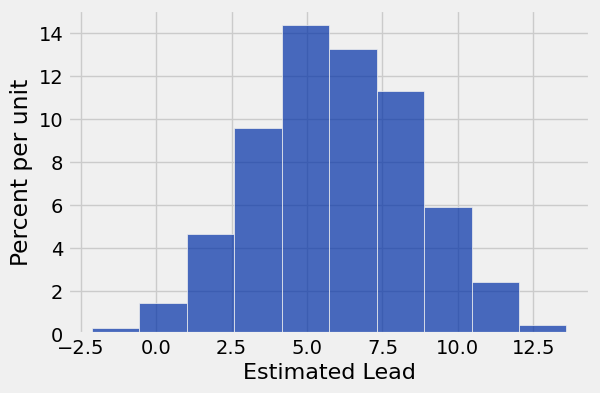

In [17]:
def leads_in_resamples():
    sampled_leads = make_array()
    for i in np.arange(2023):
        sampled_leads = np.append(sampled_leads, one_resampled_difference(votes))
    return sampled_leads

sampled_leads = leads_in_resamples()
Table().with_column('Estimated Lead', sampled_leads).hist("Estimated Lead")

<!-- END QUESTION -->

**Question 1.6.** Use the simulated data in `sampled_leads` from Question 1.5 to compute an approximate 95% confidence interval for Imm Thai's true lead over Lucky House, Thai Temple, and Thai Basil combined. **(10 Points)**


In [18]:
diff_lower_bound = percentile(2.5, sampled_leads)
diff_upper_bound = percentile(97.5, sampled_leads)
print("Bootstrapped 95% confidence interval for Imm Thai's true lead over Lucky House, Thai Temple, and Thai Basil combined: [{:f}%, {:f}%]".format(diff_lower_bound, diff_upper_bound))

Bootstrapped 95% confidence interval for Imm Thai's true lead over Lucky House, Thai Temple, and Thai Basil combined: [0.933333%, 11.066667%]


## 2. Interpreting Confidence Intervals (Cont'd)

The staff computed the following 95% confidence interval for the percentage of Imm Thai voters:

$$[50.53, 55.53]$$

(Your answer from 1.3 may have been a bit different due to randomness; that doesn't mean it was wrong!)

<!-- BEGIN QUESTION -->

**Question 2.1.** The staff also created 70%, 90%, and 99% confidence intervals from the same sample, but we forgot to label which confidence interval represented which percentages! ***First***, **match each confidence level (70%, 90%, 99%) with its corresponding interval in the cell below** (e.g. __ % CI: [52.1, 54] $\rightarrow$ replace the blank with one of the three confidence levels). ***Then***, **explain your thought process** and how you came up with your answers. **(10 Points)**

The intervals are below:

* [50.03, 55.94]
* [52.1, 54]
* [50.97, 54.99]



Understanding the relationship between confidence levels and confidence interval widths: The higher the confidence level, the greater the probability that the population parameter is included. Therefore, to ensure this, the confidence intervals should be wider.
Calculating the widths of the given confidence intervals: We calculated the width by subtracting the lower bound from the upper bound of each confidence interval.
Sorting by width: We sorted the calculated widths from smallest to largest.
Matching confidence levels to widths: We assigned the lowest confidence level (70%) to the narrowest interval, and the highest confidence level (99%) to the widest interval. We assigned the intermediate confidence level (90%) to the remaining intervals of intermediate width.

<!-- END QUESTION -->

**Question 2.2.** Suppose we produced **6,000 new samples** (each one a new/distinct uniform random sample of 1,500 students) from the population and **created a 95% confidence interval from each one**. **Roughly how many of those 6,000 intervals do you expect will actually contain the true percentage of the population?** **(10 Points)**

Assign your answer to `true_percentage_intervals`.


In [19]:
true_percentage_intervals = 6000 * 0.95

Recall the second bootstrap confidence interval you created, which estimated Imm Thai's lead over Lucky House, Thai Temple, and Thai Basil combined. Among
voters in the sample, Imm Thai's lead was 6%. The staff's 95% confidence interval for the true lead (in the population of all voters) was:

$$[1.2, 11.2]$$

Suppose we are interested in testing a simple yes-or-no question:

> "Is the percentage of votes for Imm Thai equal to the percentage of votes for Lucky House, Thai Temple, and Thai Basil combined?"

Our null hypothesis is that the percentages are equal, or equivalently, that Imm Thai's lead is exactly 0. Our alternative hypothesis is that Imm Thai's lead is not equal to 0.  In the questions below, don't compute any confidence interval yourself—use only the staff's 95% confidence interval.

> Hint: Try thinking about the width of the 95% confidence interval in comparison to the new confidence intervals in the questions below. **Drawing a picture may help.**

**Question 2.3.** Say we use a 5% p-value cutoff. Do we reject the null, fail to reject the null, or are we unable to tell using the staff's confidence interval? **(10 Points)**

Assign `cutoff_five_percent` to the number corresponding to the correct answer.

1. Reject the null / Data is consistent with the alternative hypothesis
2. Fail to reject the null / Data is consistent with the null hypothesis
3. Unable to tell using our staff confidence interval

*Hint:* Consider the relationship between the p-value cutoff and confidence. If you're confused, take a look at [this chapter](https://inferentialthinking.com/chapters/13/4/Using_Confidence_Intervals.html) of the textbook.


In [22]:
cutoff_five_percent = 1

**Question 2.4.** What if, instead, we use a p-value cutoff of 1%? Do we reject the null, fail to reject the null, or are we unable to tell using our staff confidence interval? **(10 Points)**

Assign `cutoff_one_percent` to the number corresponding to the correct answer.

1. Reject the null / Data is consistent with the alternative hypothesis
2. Fail to reject the null / Data is consistent with the null hypothesis
3. Unable to tell using our staff confidence interval


In [24]:
cutoff_one_percent = 3

**Question 2.5.** What if we use a p-value cutoff of 10%? Do we reject, fail to reject, or are we unable to tell using our confidence interval? **(10 Points)**

Assign `cutoff_ten_percent` to the number corresponding to the correct answer.

1. Reject the null / Data is consistent with the alternative hypothesis
2. Fail to reject the null / Data is consistent with the null hypothesis
3. Unable to tell using our staff confidence interval


In [26]:
cutoff_ten_percent = 1

## 3. Tennis Time
Ciara is interested in the heights of female tennis players. She’s collected a sample of 100 heights of professional women’s tennis players. She wants to use this sample to estimate the true interquartile range (IQR) of all heights of professional women’s tennis players.

**Hint:** We defined the interquartile range (IQR) to be: **75th percentile – 25th percentile**

**Question 3.1.** In order to construct a **99% confidence interval** for the IQR, what should our **upper and lower percentile endpoints** be?

99% 신뢰 구간은 데이터의 중앙 99%를 포함해야 합니다. 따라서 하위 0.5%와 상위 0.5%를 제외해야 합니다.

하한 백분위수 끝점: 0.5번째 백분위수
상한 백분위수 끝점: 99.5번째 백분위수

**Question 3.2.** Define a function `ci_iqr` that constructs a 99% confidence interval for the IQR as follows. The function takes the following arguments:
- `tbl`: A one-column table consisting of a random sample from the population; you can assume this sample is large
- `reps`: The number of bootstrap repetitions

**Hint:** To find the 25th and 75th percentile of an array, you can use the `percentile` function.

In [28]:
def ci_iqr(tbl, reps):
    stats = make_array()

    for i in np.arange(reps):
        resample_col = tbl.sample(with_replacement=True).column(0)  # Assuming the heights are in the first column
        new_iqr = percentile(75, resample_col) - percentile(25, resample_col)
        stats = np.append(stats, new_iqr)

    left_end = percentile(0.5, stats)
    right_end = percentile(99.5, stats)

    return make_array(left_end, right_end)

## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a pdf file for you to submit. **Please save before exporting!**

In [29]:
# should change the directory and file name matching to yours
!jupyter nbconvert './DS/lab19(SSU).ipynb' --to pdf

[NbConvertApp] Converting notebook ./DS/lab19(SSU).ipynb to pdf
[NbConvertApp] Support files will be in lab19(SSU)_files/
[NbConvertApp] Making directory ./lab19(SSU)_files
[NbConvertApp] Writing 78353 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 126679 bytes to DS/lab19(SSU).pdf
